In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path

# Ajoute la racine du projet
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


In [9]:
def plot_loss_curve(csv_path):
    data = np.genfromtxt(csv_path, delimiter=",", names=True, dtype=None, encoding="utf-8")
    if "epoch" not in data.dtype.names or "loss" not in data.dtype.names:
        raise ValueError("Le CSV doit contenir les colonnes 'epoch' et 'loss'.")

    epochs = data["epoch"]
    loss = data["loss"]
    best_loss = data["best_loss"] if "best_loss" in data.dtype.names else None

    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].plot(epochs, loss, label="loss")
    if best_loss is not None:
        ax[0].plot(epochs, best_loss, label="best_loss", alpha=0.8)
    ax[0].set_xlabel("Epoch")
    ax[0].set_ylabel("Loss")
    ax[0].set_title("RT28 loss")
    ax[0].legend()

    eps = 1e-12
    ax[1].plot(epochs, np.log(np.clip(loss, eps, None)), label="log(loss)")
    if best_loss is not None:
        ax[1].plot(epochs, np.log(np.clip(best_loss, eps, None)), label="log(best_loss)", alpha=0.8)
    ax[1].set_xlabel("Epoch")
    ax[1].set_ylabel("Log loss")
    ax[1].set_title("RT28 log loss")
    ax[1].legend()

    fig.tight_layout()
    plt.show()

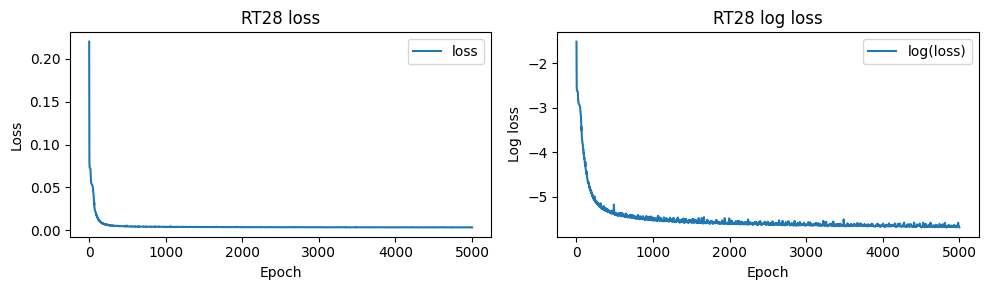

In [10]:
csv_path = "out/phyfid_training.csv"
plot_loss_curve(csv_path)